# PhyGHT Dataset Walkthrough

This notebook provides a guide to understanding the structure of the **PhyGHT** dataset. 

The raw data is stored as nested **Awkward Arrays**, representing the hierarchical structure of particle collision events:
1.  **Events**: Each entry is a collision event.
2.  **Jets**: Each event contains a variable number of jets.
3.  **Tracks**: Each event contains a global list of tracks (particles).
4.  **Indices**: A mapping that links specific Jets to their constituent Tracks.

## Dependencies
Ensure you have the required libraries installed:
```bash
pip install awkward numpy matplotlib vector
```

In [1]:
import pickle
import awkward as ak
import numpy as np
import vector
import matplotlib.pyplot as plt
import os

# Set plotting style
plt.style.use('seaborn-v0_8-paper')
vector.register_awkward()

## 1. Loading the Raw Data

The data is stored in `.pkl` files. We will load one of the raw datasets (e.g., `mu60_10k_events_data.pkl`).

> **Note:** Adjust the path below if your notebook is not directly in the `data/` folder.

In [ ]:
# Path to the raw data file
DATA_PATH = "raw_data/mu60_10k_events_data.pkl"
# DATA_PATH = "raw_data/mu200_10k_events_data.pkl"

if not os.path.exists(DATA_PATH):
    print(f"WARNING: File not found at {DATA_PATH}. Please check the path.")
else:
    print(f"Loading data from {DATA_PATH}...")
    with open(DATA_PATH, "rb") as f:
        data_dict = pickle.load(f)
    print("Data loaded successfully!")

Loading data from raw_data/mu60_10k_events_data.pkl...
Data loaded successfully!


## 2. Understanding the Data Structure

The dictionary contains three main keys:

* **`jets`**: Properties of the jets found in the event (clustered objects).
* **`trks`**: Properties of all tracks (charged particles) in the event.
* **`jet_trk_IDs`**: Indices linking jets to tracks. This defines the **Hypergraph** structure (Jet = Hyperedge, Track = Node).

In [3]:
# Extract arrays
jet_array = data_dict["jets"]
trk_array = data_dict["trks"]
jet_trk_idx = data_dict["jet_trk_IDs"]

print("--- Data Shapes (Awkward Arrays) ---")
print(f"Jets Array Type:   {jet_array.type}")
print(f"Tracks Array Type: {trk_array.type}")
print(f"Indices Array Type:{jet_trk_idx.type}")

print(f"\nTotal Number of Events: {len(jet_array)}")

--- Data Shapes (Awkward Arrays) ---
Jets Array Type:   10000 * var * var * float64
Tracks Array Type: 10000 * var * var * float64
Indices Array Type:10000 * var * var * int64

Total Number of Events: 10000


### 2.1 Jet Features

The `jet_array` has shape `[Event, Jet, Feature]`. 
The first four columns are features and the last two are targets: `[pT, eta, phi, mass, Efrac, Mfrac]`.

* **pT**: Transverse Momentum
* **eta**: Pseudorapidity (spatial coordinate)
* **phi**: Azimuthal angle (spatial coordinate)
* **mass**: Mass of the jet
* **Efrac**: Energy Fraction (Target for Regression)
* **Mfrac**: Mass Fraction (Target for Regression)

In [16]:
# Example: Inspect the first jet of the first event
first_jet = jet_array[0, 0]
print("First Jet Features:", first_jet)

# Construct a 4-vector for easier physics manipulations
jets_p4 = ak.zip(
    {
        "pt": jet_array[:, :, 0],
        "eta": jet_array[:, :, 1],
        "phi": jet_array[:, :, 2],
        "mass": jet_array[:, :, 3],
        "Efrac": jet_array[:, :, -2], # Second to last
        "Mfrac": jet_array[:, :, -1], # Last
    },
    with_name="Momentum4D",
)

print(f"\nJet 4-Vector (Event 0, Jet 0):\n {jets_p4[0, 0]}")

First Jet Features: [123, 2.84, 4.46, 33, 0.765, 0.473]

Jet 4-Vector (Event 0, Jet 0):
 {pt: 123, eta: 2.84, phi: 4.46, mass: 33, Efrac: 0.765, Mfrac: 0.473}


### 2.2 Track Features & Labels

The `trk_array` has shape `[Event, Track, Feature]`. 
The first six columns are features and the last one is the label: `[pT, eta, phi, m, d0, z0, label]`.

* **pT**: Transverse Momentum
* **eta**: Pseudorapidity (spatial coordinate)
* **phi**: Azimuthal angle (spatial coordinate)
* **m**: Mass of the track
* **d0**: Transverse impact parameter
* **z0**: Longitudinal impact parameter

**The Label:**
* The last column (`-1`) contains the truth label.
* **-1**: Hard Scatter (Signal) Track.
* **>= 0**: Pileup (Noise) Track.

In [ ]:
# Define masks for Signal (HS) vs Pileup (PU)
track_labels = trk_array[:, :, -1]

is_hs_mask = (track_labels == -1)
is_pu_mask = ~is_hs_mask

# Create 4-vectors for tracks
trks_p4 = ak.zip(
    {
        "pt": trk_array[:, :, 0],
        "eta": trk_array[:, :, 1],
        "phi": trk_array[:, :, 2],
        "mass": trk_array[:, :, 3],
    },
    with_name="Momentum4D",
)

print(f"Event 0 has {len(trks_p4[0])} tracks.")
print(f"  -> {ak.sum(is_hs_mask[0])} Signal Tracks")
print(f"  -> {ak.sum(is_pu_mask[0])} Pileup Tracks")

Event 0 has 2037 tracks.
  -> 130 Signal Tracks
  -> 1907 Pileup Tracks


## 3. Physics Analysis & Visualization

Let's visualize the difference between **High Energy Fraction** jets (likely Signal) and **Low Energy Fraction** jets (likely Pileup).

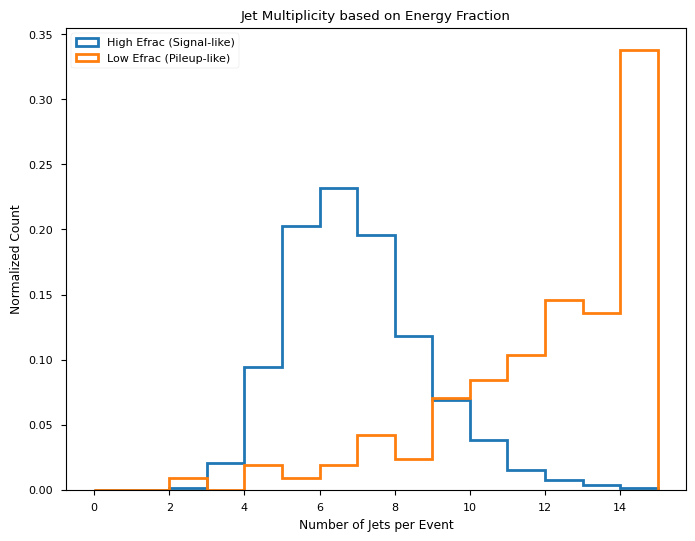

In [11]:
# 1. Define High vs Low Efrac Jets
high_efrac_mask = jets_p4.Efrac > 0.3
low_efrac_mask = ~high_efrac_mask

# 2. Count jets per event
n_high = ak.num(jets_p4[high_efrac_mask], axis=1)
n_low = ak.num(jets_p4[low_efrac_mask], axis=1)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.hist(n_high, bins=15, range=(0, 15), histtype='step', lw=2, label='High Efrac (Signal-like)', density=True)
plt.hist(n_low, bins=15, range=(0, 15), histtype='step', lw=2, label='Low Efrac (Pileup-like)', density=True)
plt.xlabel("Number of Jets per Event")
plt.ylabel("Normalized Count")
plt.title("Jet Multiplicity based on Energy Fraction")
plt.legend()
plt.show()

### Track Kinematics: Signal vs. Pileup

We can observe distinct kinematic differences between signal tracks (from the hard scatter) and pileup tracks.

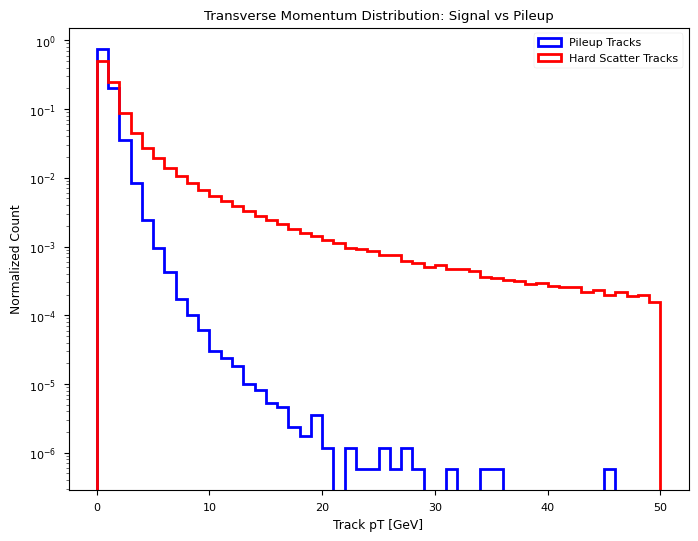

In [12]:
# Flatten arrays for plotting (combining all events)
hs_pt = ak.flatten(trks_p4[is_hs_mask].pt)
pu_pt = ak.flatten(trks_p4[is_pu_mask].pt)

plt.figure(figsize=(8, 6))
plt.hist(pu_pt, bins=50, range=(0, 50), histtype='step', lw=2, label='Pileup Tracks', color='blue', density=True)
plt.hist(hs_pt, bins=50, range=(0, 50), histtype='step', lw=2, label='Hard Scatter Tracks', color='red', density=True)

plt.xlabel("Track pT [GeV]")
plt.ylabel("Normalized Count")
plt.title("Transverse Momentum Distribution: Signal vs Pileup")
plt.yscale('log') # Log scale helps see the high-pT tail of signal tracks
plt.legend()
plt.show()

## 4. The Hypergraph Structure (Jets $\leftrightarrow$ Tracks)

The `jet_trk_IDs` array is critical. It contains the **global indices** of tracks that belong to specific jets.

Structure: `[Event][Jet_Index][List_of_Track_Indices]`

Jet 0 in Event 0 has 30 constituent tracks.
Track IDs: [989, 6244, 101, 1821, 59, 1360, 5949, ..., 23, 4466, 1571, 185, 184, 6857, 24]


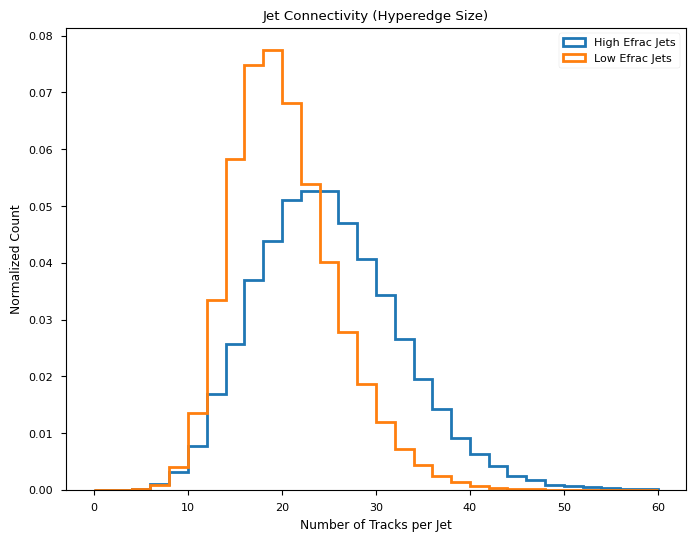

In [ ]:
# Let's look at the constituents of the first jet in the first event
event_idx = 0
jet_idx = 0

# Get Track IDs belonging to this jet
constituent_ids = jet_trk_idx[event_idx, jet_idx]
print(f"Jet {jet_idx} in Event {event_idx} has {len(constituent_ids)} constituent tracks.")
print(f"Track IDs: {constituent_ids}")

# Access specific properties of these tracks using the ID map
num_trks_per_jet = ak.num(jet_trk_idx, axis=2)

plt.figure(figsize=(8, 6))
plt.hist(ak.flatten(num_trks_per_jet[high_efrac_mask]), bins=30, range=(0, 60), 
         histtype='step', lw=2, label='High Efrac Jets', density=True)
plt.hist(ak.flatten(num_trks_per_jet[low_efrac_mask]), bins=30, range=(0, 60), 
         histtype='step', lw=2, label='Low Efrac Jets', density=True)
plt.xlabel("Number of Tracks per Jet")
plt.ylabel("Normalized Count")
plt.title("Jet Connectivity (Hyperedge Size)")
plt.legend()
plt.show()

## 5. Missing Transverse Energy (MET) Check

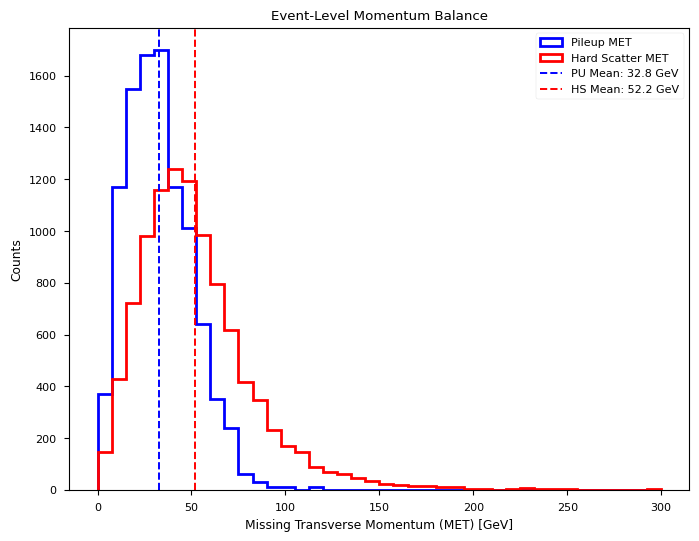

In [15]:
# Calculate Vector Sum of pT for HS and PU tracks separately
sum_p4_hs = ak.sum(trks_p4[is_hs_mask], axis=1)
sum_p4_pu = ak.sum(trks_p4[is_pu_mask], axis=1)

plt.figure(figsize=(8, 6))
plt.hist(sum_p4_pu.pt, bins=40, range=(0, 300), histtype='step', lw=2, label='Pileup MET', color='blue')
plt.hist(sum_p4_hs.pt, bins=40, range=(0, 300), histtype='step', lw=2, label='Hard Scatter MET', color='red')

plt.axvline(np.mean(sum_p4_pu.pt), color='blue', linestyle='--', label=f'PU Mean: {np.mean(sum_p4_pu.pt):.1f} GeV')
plt.axvline(np.mean(sum_p4_hs.pt), color='red', linestyle='--', label=f'HS Mean: {np.mean(sum_p4_hs.pt):.1f} GeV')

plt.xlabel("Missing Transverse Momentum (MET) [GeV]")
plt.ylabel("Counts")
plt.title("Event-Level Momentum Balance")
plt.legend()
plt.show()